In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
import kagglehub

import tensorflow as tf   # только для загрузки TFRecord

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Все 12 входных каналов датасета (в порядке как они записаны)
ALL_FEATURES = [
    'elevation',   # 0  — рельеф (высота над уровнем моря)
    'th',          # 1  — направление ветра (градусы)
    'vs',          # 2  — скорость ветра (м/с)
    'tmmn',        # 3  — минимальная температура (К)
    'tmmx',        # 4  — максимальная температура (К)
    'sph',         # 5  — влажность воздуха
    'pr',          # 6  — осадки (мм)
    'pdsi',        # 7  — индекс засухи PDSI
    'NDVI',        # 8  — индекс растительности (насколько густой лес)
    'population',  # 9  — плотность населения
    'erc',         # 10 — индекс пожарной опасности (Energy Release Component)
    'PrevFireMask' # 11 — маска пожара ВЧЕРА (аналог входа в GoL)
]

# Статистика для нормализации (из оригинального датасета)
DATA_STATS = {
    'elevation': (0.0,    3141.0,  657.3003, 649.0147),
    'th':        (0.,      360.0,  190.3298,  72.5985),
    'vs':        (0.0,      10.02,   3.8501,   1.4110),
    'tmmn':      (253.15,  298.95, 281.0877,   8.9824),  #(290 K - 281.0877) / 8.9824 = 0.99 -> [0;1]
    'tmmx':      (253.15,  315.09, 295.1738,   9.8155),
    'sph':       (0.,        1.0,   0.00717,  0.00428),
    'pr':        (0.0,      44.53,   1.7398,   4.4828),
    'pdsi':      (-6.13,    7.876, -0.00527,   2.6823),
    'NDVI':      (-9821.,  9996.,  5157.625, 2466.668),
    'population':(0.,     2534.06,  25.5314, 154.7233),
    'erc':       (0.0,    106.249,  37.3263,  20.8460),
    'PrevFireMask': (-1., 1., 0., 1.),
    'FireMask':     (-1., 1., 0., 1.),
}

DATA_SIZE   = 64   # исходный размер патча в датасете
SAMPLE_SIZE = 32   # размер после кропа (32×32 пикселя = 32×32 км²)

#### Загрузка и парсинг TFRecord

In [2]:
def parse_tfrecord(example_proto):

    feature_names = ALL_FEATURES + ['FireMask']  # 12 входов + 1 выход

    # Описываем схему: каждый канал 64*64 = 4096 float32
    feature_description = {
        name: tf.io.FixedLenFeature([DATA_SIZE * DATA_SIZE], tf.float32)
        for name in feature_names
    }

    parsed = tf.io.parse_single_example(example_proto, feature_description)

    # Превращаем плоский вектор в матрицу 64×64
    return {name: tf.reshape(parsed[name], (DATA_SIZE, DATA_SIZE))
            for name in feature_names}


def normalize_channel(tensor, key):

    min_val, max_val, mean, std = DATA_STATS[key]
    tensor = tf.clip_by_value(tensor, min_val, max_val)

    if key in ('PrevFireMask', 'FireMask'):
        # Просто клипаем: -1 в 0, 0 в 0, 1 в 1
        return tf.clip_by_value(tensor, 0., 1.)
    else:
        # Z-нормализация: среднее=0, std=1 -> дополнительно в [0,1]
        normalized = (tensor - mean) / (std + 1e-8)
        # Ограничиваем в [-3, 3] стандартных отклонения, потом в [0,1]
        normalized = tf.clip_by_value(normalized, -3., 3.)
        return (normalized + 3.) / 6.


def load_tfrecord_to_numpy(file_pattern, max_samples=None):

    files = glob.glob(file_pattern)
    if not files:
        raise FileNotFoundError(f"Файлы не найдены: {file_pattern}")
    print(f"Найдено файлов: {len(files)}")

    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)

    all_X, all_y = [], []

    for i, example in enumerate(tqdm(dataset, desc="Загрузка")):
        if max_samples and i >= max_samples:
            break

        # Строим тензор входа: 12 каналов, каждый нормализован
        channels = []
        for feat in ALL_FEATURES:
            ch = normalize_channel(example[feat], feat).numpy()  # (64, 64)
            channels.append(ch)
        X_sample = np.stack(channels, axis=0)  # (12, 64, 64)

        # Целевая маска (бинарная: горит / не горит)
        y_raw = example['FireMask'].numpy()     # (64, 64)
        y_sample = (y_raw > 0).astype(np.float32)  # -1 (unlabeled) → 0
        y_sample = y_sample[np.newaxis, :, :]   # (1, 64, 64)

        # Центральный кроп 32×32 (убираем граничные артефакты)
        start = (DATA_SIZE - SAMPLE_SIZE) // 2   # = 16
        end   = start + SAMPLE_SIZE              # = 48
        X_sample = X_sample[:, start:end, start:end]  # (12, 32, 32)
        y_sample = y_sample[:, start:end, start:end]  # (1,  32, 32)

        all_X.append(X_sample)
        all_y.append(y_sample)

    X = np.stack(all_X, axis=0).astype(np.float32)  # (N, 12, 32, 32)
    y = np.stack(all_y, axis=0).astype(np.float32)  # (N,  1, 32, 32)

    print(f"Загружено: X={X.shape}, y={y.shape}")
    print(f"Горящих пикселей: {y.mean()*100:.2f}%  (остальные — не горят)")
    return X, y

In [3]:
path = kagglehub.dataset_download("fantineh/next-day-wildfire-spread")

print("Path to dataset files:", path)

100%|██████████| 2.08G/2.08G [00:24<00:00, 89.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2


In [4]:
path = r"/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2"

for root, dirs, files in os.walk(path):
    for f in files[:10]:
        print(os.path.join(root, f))

/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_08.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_09.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_11.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_05.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_06.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_12.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_train_14.tfrecord
/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2/next_day_wildfire_spread_test_00.tfrecord
/root/.cache/kagglehub/datasets/fantineh/

In [5]:
path = r"/root/.cache/kagglehub/datasets/fantineh/next-day-wildfire-spread/versions/2"

TRAIN_PATTERN = os.path.join(path, "next_day_wildfire_spread_train_*.tfrecord")
VAL_PATTERN   = os.path.join(path, "next_day_wildfire_spread_eval_*.tfrecord")
TEST_PATTERN  = os.path.join(path, "next_day_wildfire_spread_test_*.tfrecord")

print("Train файлов:", len(glob.glob(TRAIN_PATTERN)))
print("Val файлов:",   len(glob.glob(VAL_PATTERN)))
print("Test файлов:",  len(glob.glob(TEST_PATTERN)))

Train файлов: 15
Val файлов: 2
Test файлов: 2


In [6]:
X_train, y_train = load_tfrecord_to_numpy(TRAIN_PATTERN, max_samples=3000)
X_val,   y_val   = load_tfrecord_to_numpy(VAL_PATTERN,   max_samples=500)
X_test,  y_test  = load_tfrecord_to_numpy(TEST_PATTERN,  max_samples=500)

Найдено файлов: 15


Загрузка: 3000it [00:29, 100.57it/s]


Загружено: X=(3000, 12, 32, 32), y=(3000, 1, 32, 32)
Горящих пикселей: 3.64%  (остальные — не горят)
Найдено файлов: 2


Загрузка: 500it [00:05, 88.05it/s] 


Загружено: X=(500, 12, 32, 32), y=(500, 1, 32, 32)
Горящих пикселей: 4.47%  (остальные — не горят)
Найдено файлов: 2


Загрузка: 500it [00:04, 110.07it/s]

Загружено: X=(500, 12, 32, 32), y=(500, 1, 32, 32)
Горящих пикселей: 4.72%  (остальные — не горят)


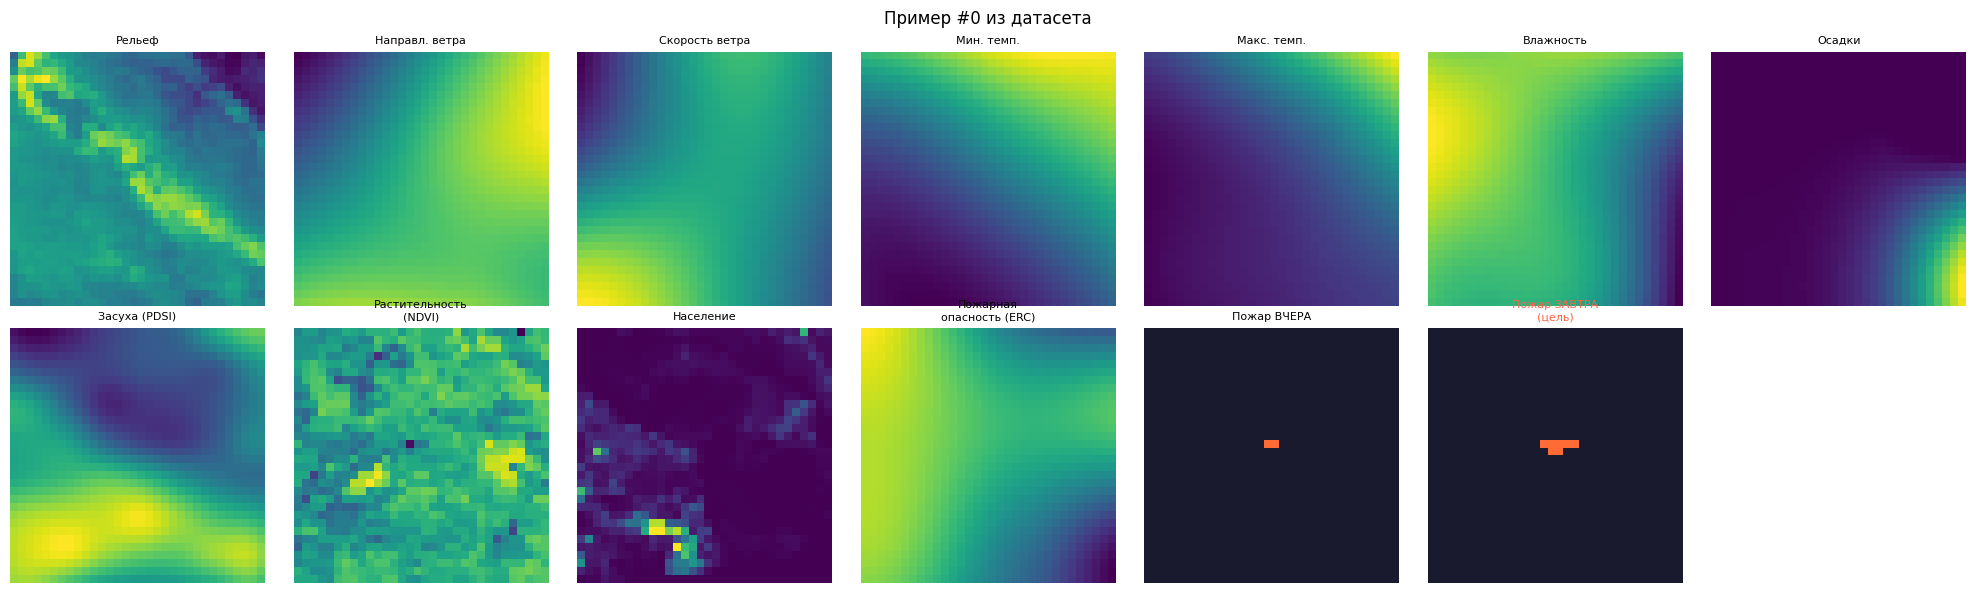

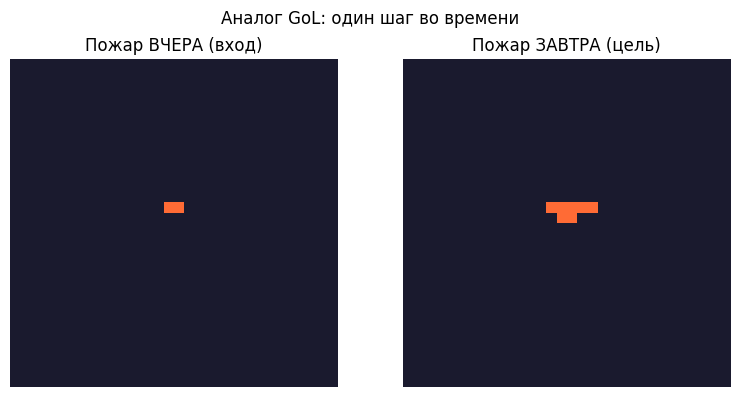

In [7]:
CHANNEL_NAMES = [
    'Рельеф', 'Направл. ветра', 'Скорость ветра',
    'Мин. темп.', 'Макс. темп.', 'Влажность',
    'Осадки', 'Засуха (PDSI)', 'Растительность\n(NDVI)',
    'Население', 'Пожарная\nопасность (ERC)', 'Пожар ВЧЕРА'
]

def visualize_sample(X, y, idx=0):

    fig, axes = plt.subplots(2, 7, figsize=(20, 6))
    axes = axes.flatten()

    # Цветовая схема для масок пожара
    fire_cmap = mcolors.ListedColormap(['#1a1a2e', '#ff6b35'])

    for ch in range(12):
        ax = axes[ch]
        if ch == 11:  # PrevFireMask — бинарный
            ax.imshow(X[idx, ch], cmap=fire_cmap, vmin=0, vmax=1)
        else:
            ax.imshow(X[idx, ch], cmap='viridis')
        ax.set_title(CHANNEL_NAMES[ch], fontsize=8)
        ax.axis('off')

    # Целевая маска
    axes[12].imshow(y[idx, 0], cmap=fire_cmap, vmin=0, vmax=1)
    axes[12].set_title('Пожар ЗАВТРА\n(цель)', fontsize=8, color='tomato')
    axes[12].axis('off')

    axes[13].axis('off')

    plt.suptitle(f'Пример #{idx} из датасета', fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_sample(X_train, y_train, idx=0)

# Смотрим на аналог GoL: только PrevFireMask → FireMask
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fire_cmap = mcolors.ListedColormap(['#1a1a2e', '#ff6b35'])
ax1.imshow(X_train[0, 11], cmap=fire_cmap); ax1.set_title('Пожар ВЧЕРА (вход)'); ax1.axis('off')
ax2.imshow(y_train[0, 0],  cmap=fire_cmap); ax2.set_title('Пожар ЗАВТРА (цель)'); ax2.axis('off')
plt.suptitle('Аналог GoL: один шаг во времени')
plt.tight_layout(); plt.show()

![image.png](attachment:6938441a-1de4-4baa-b605-fc370b78846e.png)

In [8]:
class WildfireDataset(Dataset):

    def __init__(self, X, y, channel_indices):
        self.X = torch.from_numpy(X[:, channel_indices])  # (N, n_ch, 32, 32)
        self.y = torch.from_numpy(y)                       # (N,  1, 32, 32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class WildfireCNN(nn.Module):

    def __init__(self, in_channels):
        super().__init__()

        self.net = nn.Sequential(
            # Слой 1: детекция локальных паттернов (как conv1 в GoL)
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Слой 2: комбинирование паттернов от соседних клеток
            # Рецептивное поле теперь 5×5 (два слоя по 3×3)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Слой 3: сжатие признаков
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Слой 4: финальная бинарная сегментация (как conv2 в GoL)
            nn.Conv2d(32, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# Быстрая проверка: прогоняем случайный тензор
test_input = torch.randn(4, 2, 32, 32)  # батч из 4, 2 канала, 32×32
test_model = WildfireCNN(in_channels=2)
test_output = test_model(test_input)
print(f"Вход: {test_input.shape}  -  Выход: {test_output.shape}")
print(f"Выход в диапазоне [0,1]: мин={test_output.min():.3f}, макс={test_output.max():.3f}")

total_params = sum(p.numel() for p in test_model.parameters())
print(f"Параметров в модели: {total_params:,}")

Вход: torch.Size([4, 2, 32, 32])  -  Выход: torch.Size([4, 1, 32, 32])
Выход в диапазоне [0,1]: мин=0.257, макс=0.828
Параметров в модели: 37,857


#### метрика IoU

IoU = $\frac{|предсказанный пожар (пересечение) реальный пожар|}{|предсказанный пожар (объединение) реальный пожар|}$

= 1.0 - идеальное предсказание

= 0.0 - полное несовпадение

In [9]:
def iou_score(pred_binary, target):

    intersection = (pred_binary * target).sum(dim=(1, 2, 3))     # по H, W, C
    union        = (pred_binary + target).clamp(0, 1).sum(dim=(1, 2, 3))
    # Если union=0 (нет пожара ни в pred ни в target), то IoU=1 (оба верно пусты)
    iou = torch.where(union == 0,
                      torch.ones_like(union),
                      intersection.float() / union.float())
    return iou.mean().item()


class WeightedBCEDiceLoss(nn.Module):

    def __init__(self, weight_fire=10.0):
        super().__init__()
        self.weight_fire = weight_fire

    def forward(self, pred, target):
        # BCE с весами
        weights = target * self.weight_fire + (1 - target) * 1.0
        bce = nn.functional.binary_cross_entropy(pred, target, weight=weights)

        # Dice Loss
        smooth = 1e-6
        pred_flat   = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = 1 - (2. * intersection + smooth) / \
               (pred_flat.sum() + target_flat.sum() + smooth)

        return bce + dice

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")


def train_and_evaluate(channel_indices, epochs=10, batch_size=32, lr=1e-3):

    n_channels = len(channel_indices)
    channel_names_used = [ALL_FEATURES[i] for i in channel_indices]
    print(f"\n{'='*55}")
    print(f"Каналы ({n_channels}): {channel_names_used}")
    print('='*55)

    # Датасеты и загрузчики
    train_ds = WildfireDataset(X_train, y_train, channel_indices)
    val_ds   = WildfireDataset(X_val,   y_val,   channel_indices)
    test_ds  = WildfireDataset(X_test,  y_test,  channel_indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    # Модель
    model = WildfireCNN(in_channels=n_channels).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = WeightedBCEDiceLoss(weight_fire=10.0)

    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}
    best_val_iou = 0.0
    best_state   = None

    for epoch in range(1, epochs + 1):
        #  Обучение
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        #  Валидация
        model.eval()
        val_losses, val_ious = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_losses.append(criterion(pred, y_batch).item())
                pred_bin = (pred > 0.5).float()
                val_ious.append(iou_score(pred_bin, y_batch))

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        val_iou    = np.mean(val_ious)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:>2}/{epochs} | "
              f"train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | "
              f"val_IoU={val_iou:.4f}")

    # Тест на лучших весах
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    test_ious = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred_bin = (model(X_batch) > 0.5).float()
            test_ious.append(iou_score(pred_bin, y_batch))

    test_iou = np.mean(test_ious)
    print(f"\n→ Тестовый IoU: {test_iou:.4f}")

    history['test_iou']     = test_iou
    history['model']        = model
    history['best_state']   = best_state
    history['channel_names']= channel_names_used
    return history

print("Функция обучения определена ✓")

Устройство: cpu
Функция обучения определена ✓


In [11]:
ABLATION_STEPS = [
    ([11],              "1: Только пожар вчера (аналог GoL)"),
    ([11, 8],           "2: + Растительность (NDVI)"),
    ([11, 8, 10],       "3: + Пожарная опасность (ERC)"),
    ([11, 8, 10, 2, 1], "4: + Ветер (скорость + направление)"),
    ([11, 8, 10, 2, 1, 7], "5: + Засуха (PDSI)"),
    (list(range(12)),   "6: Все 12 каналов"),
]

EPOCHS = 20  # увеличь до 20-30 для лучшего результата

ablation_results = []

for channel_indices, label in ABLATION_STEPS:
    print(f"\n\n>>> {label}")
    history = train_and_evaluate(
        channel_indices=channel_indices,
        epochs=EPOCHS,
        batch_size=32
    )
    ablation_results.append({
        'label':    label,
        'n_ch':     len(channel_indices),
        'test_iou': history['test_iou'],
        'history':  history
    })

print("\n\n" + "="*55)
print("ИТОГИ ABLATION STUDY")
print("="*55)
prev_iou = None
for r in ablation_results:
    delta = f"  (+{r['test_iou']-prev_iou:.4f})" if prev_iou is not None else ""
    print(f"{r['label']:<40} IoU = {r['test_iou']:.4f}{delta}")
    prev_iou = r['test_iou']



>>> 1: Только пожар вчера (аналог GoL)

Каналы (1): ['PrevFireMask']
Epoch  1/20 | train_loss=1.5325 | val_loss=1.5668 | val_IoU=0.2266
Epoch  2/20 | train_loss=1.3727 | val_loss=1.5411 | val_IoU=0.2278
Epoch  3/20 | train_loss=1.3371 | val_loss=1.5333 | val_IoU=0.2331
Epoch  4/20 | train_loss=1.3294 | val_loss=1.5649 | val_IoU=0.2284
Epoch  5/20 | train_loss=1.3279 | val_loss=1.5441 | val_IoU=0.2367
Epoch  6/20 | train_loss=1.3270 | val_loss=1.5578 | val_IoU=0.2350
Epoch  7/20 | train_loss=1.3252 | val_loss=1.5957 | val_IoU=0.2341
Epoch  8/20 | train_loss=1.3231 | val_loss=1.5842 | val_IoU=0.2293
Epoch  9/20 | train_loss=1.3200 | val_loss=1.5878 | val_IoU=0.2346
Epoch 10/20 | train_loss=1.3187 | val_loss=1.5684 | val_IoU=0.2349
Epoch 11/20 | train_loss=1.3211 | val_loss=1.5674 | val_IoU=0.2354
Epoch 12/20 | train_loss=1.3162 | val_loss=1.5673 | val_IoU=0.2352
Epoch 13/20 | train_loss=1.3183 | val_loss=1.5664 | val_IoU=0.2357
Epoch 14/20 | train_loss=1.3185 | val_loss=1.5721 | val_Io

In [12]:
for name, pattern in [('Train', TRAIN_PATTERN),
                       ('Val',   VAL_PATTERN),
                       ('Test',  TEST_PATTERN)]:

    files = glob.glob(pattern)
    count = 0
    for f in files:
        count += sum(1 for _ in tf.data.TFRecordDataset(f))

    print(f"{name}: {count} примеров  ({len(files)} файлов)")

Train: 14979 примеров  (15 файлов)
Val: 1877 примеров  (2 файлов)
Test: 1689 примеров  (2 файлов)


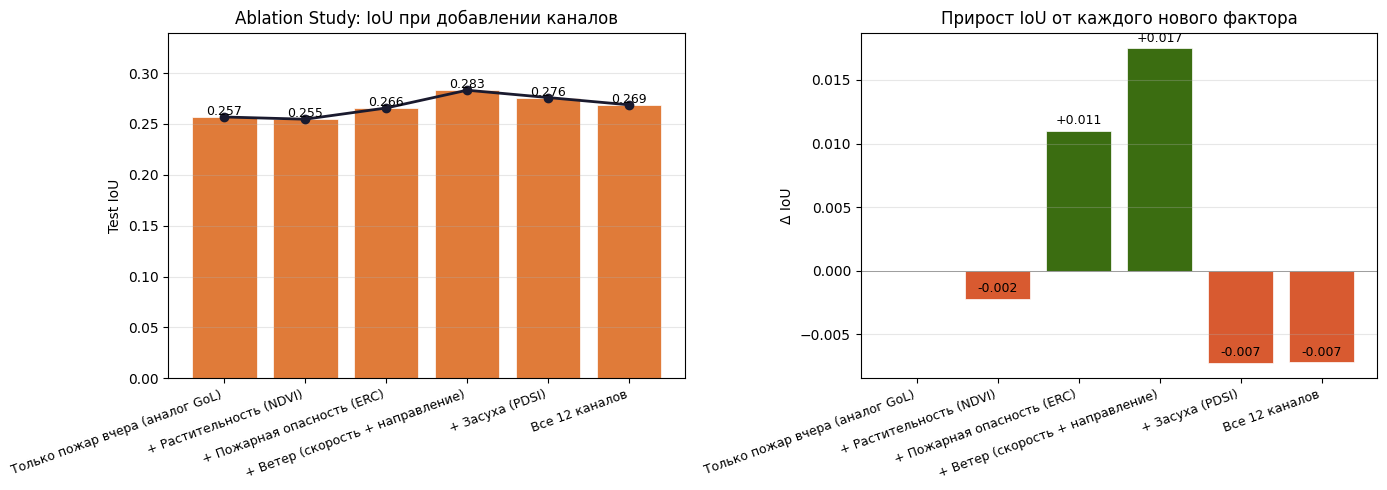

In [13]:
labels   = [r['label'].split(':')[1].strip() for r in ablation_results]
iou_vals = [r['test_iou'] for r in ablation_results]
deltas   = [0] + [iou_vals[i] - iou_vals[i-1] for i in range(1, len(iou_vals))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Левый: IoU по шагам ablation
bars = ax1.bar(range(len(labels)), iou_vals, color='#e07b39', edgecolor='white', linewidth=0.5)
ax1.plot(range(len(labels)), iou_vals, 'o-', color='#1a1a2e', linewidth=2, markersize=6)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Test IoU')
ax1.set_title('Ablation Study: IoU при добавлении каналов')
ax1.set_ylim(0, max(iou_vals) * 1.2)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(iou_vals):
    ax1.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

# Правый: прирост IoU от каждого нового канала
colors_delta = ['#3B6D11' if d >= 0 else '#D85A30' for d in deltas]
ax2.bar(range(len(labels)), deltas, color=colors_delta, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Δ IoU')
ax2.set_title('Прирост IoU от каждого нового фактора')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(deltas):
    if v != 0:
        ax2.text(i, v + 0.0005, f'+{v:.3f}' if v > 0 else f'{v:.3f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

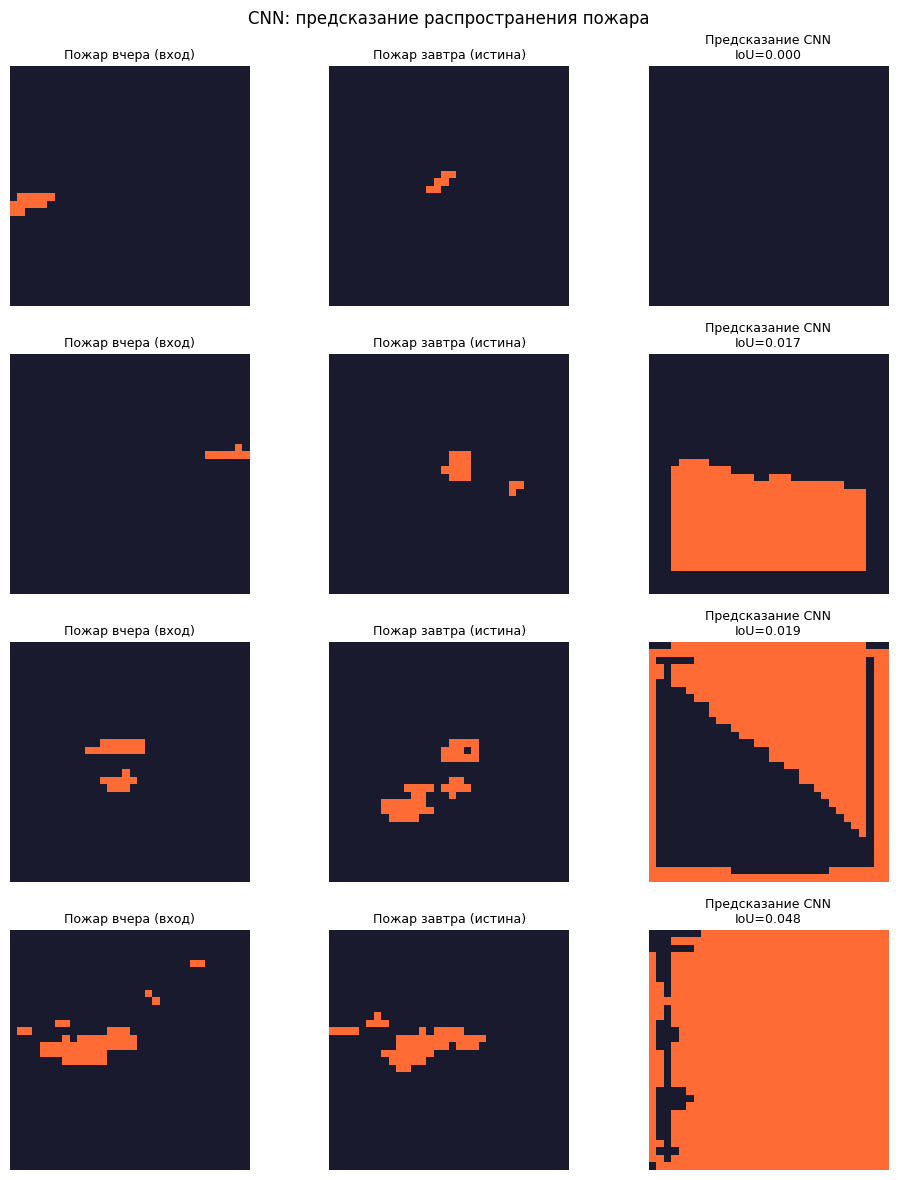

In [14]:
def visualize_predictions(model, X_data, y_data, channel_indices, n_samples=4):
    """Показывает: пожар вчера | пожар завтра (истина) | предсказание CNN."""
    fire_cmap = mcolors.ListedColormap(['#1a1a2e', '#ff6b35'])

    model.eval()
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, n_samples * 3))

    indices = np.random.choice(len(X_data), n_samples, replace=False)

    for row, idx in enumerate(indices):
        X_sample = torch.from_numpy(
            X_data[idx:idx+1, channel_indices]
        ).to(device)

        with torch.no_grad():
            pred_prob = model(X_sample)[0, 0].cpu().numpy()
        pred_bin = (pred_prob > 0.5).astype(float)

        # Пожар вчера (последний канал из входа = PrevFireMask)
        prev_fire = X_data[idx, 11]  # всегда берём из исходных данных
        true_fire = y_data[idx, 0]

        iou = iou_score(
            torch.from_numpy(pred_bin[None, None]),
            torch.from_numpy(true_fire[None, None])
        )

        axes[row, 0].imshow(prev_fire,  cmap=fire_cmap, vmin=0, vmax=1)
        axes[row, 0].set_title('Пожар вчера (вход)', fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(true_fire, cmap=fire_cmap, vmin=0, vmax=1)
        axes[row, 1].set_title('Пожар завтра (истина)', fontsize=9)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_bin,  cmap=fire_cmap, vmin=0, vmax=1)
        axes[row, 2].set_title(f'Предсказание CNN\nIoU={iou:.3f}', fontsize=9)
        axes[row, 2].axis('off')

    plt.suptitle('CNN: предсказание распространения пожара', fontsize=12)
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Используем лучшую модель (последний шаг ablation — все 12 каналов)
best_result = max(ablation_results, key=lambda r: r['test_iou'])
best_model  = best_result['history']['model']
best_channels = list(range(5))  # или тот набор что дал лучший IoU

visualize_predictions(best_model, X_test, y_test, best_channels, n_samples=4)